## Project : Machine learning for portfolio management

#### Arnaud Capitan

___

#### $$\underline{\text{Subject : the impact of interest rates on exchange rates}}$$

### Introduction :

The goal of the project is to make profit on exchange rates based on the value of interest rates.

Here are the key steps of the project :

- Extracting data
- Building and training models
- Analysing the results

Foreign exchange markets are among the most liquid markets, allowing me to have a lot of data to use, but also making it very difficult to predict correctly. EUR/US is the most traded pair currency in the world. What makes this project compelling is using regressors to predict the future exchange rates, as we have a lot of data on hand, I except at least one of the different models to correctly predict future exchange rates. I also take into account transaction costs, which is adding a challenge to my simulation as it can tank the PnL.

Adding other pairs may have helped with increasing the final PnL, as there can be correlations between the ECB's rates and the US/GBP exchange rate for example. I decided to stick with the EURO/US exchange rate.

#### Project Contributions :

The key contributions are : 
- The datasets, which I directly downloaded from the FED and ECB
- The time lag of 2 days to make predictions, as the EURIBOR mentioned a time delay of 1 day before giving the current yield (both for 10Y and 6M), requiring two days (worse case) between the available yields and the predicted values
- The train-validation-test split, with the hyper-parameters optimization

All those aspects are key elements in the project, and are described further on.


___

#### Librairies :

In [ ]:
# Extracting financial data for machine learning models
import requests
import xml.etree.ElementTree as ET #Allows to parse XML files as a tree structure
import csv
from IPython.display import Image, display
import pandas as pd
from functools import reduce
import os

# Machine Learning imports to analyse extracted data
import numpy as np
import itertools
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

___

First, we need to download the exchange rates US/EURO from the European Central Bank website. The XML file looks like this :

In [151]:
# Create directory if it doesn't exist
rep = "data/Initial test/" 
os.makedirs(rep, exist_ok=True)
rep = "data/Final test/" 
os.makedirs(rep, exist_ok=True)

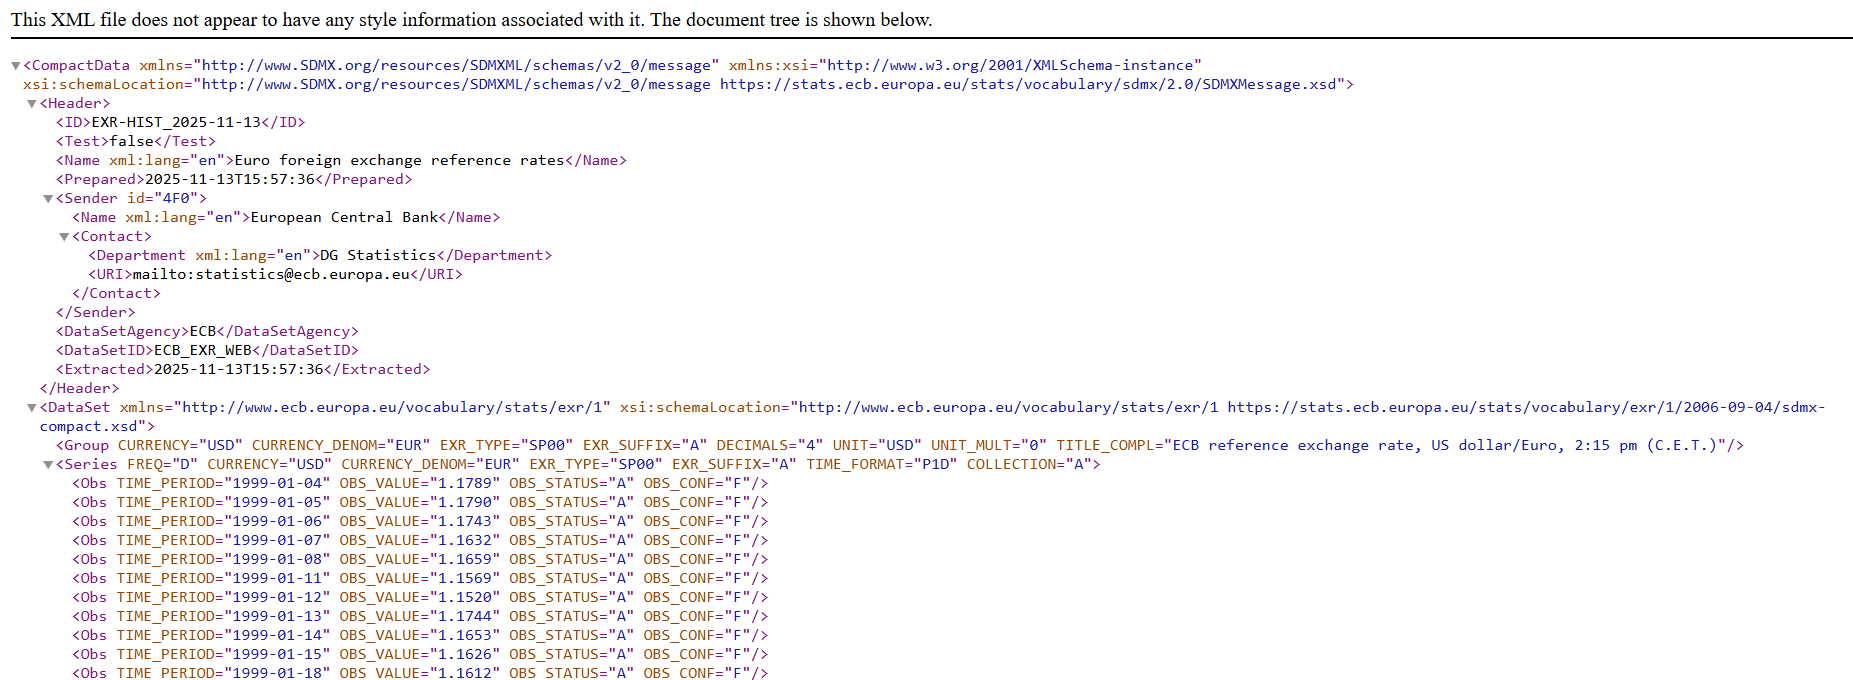

In [152]:
try:
    display(Image("data/Parsing.png", width=1400))
except:
    pass

In [153]:
def download_ecb_data(url, output_file):
    try:
        print(f"Downloading data from {url}")
        response = requests.get(url)
        response.raise_for_status()
        root = ET.fromstring(response.content) # Parse the XML into a tree structure
        namespaces = {'ns': 'http://www.ecb.europa.eu/vocabulary/stats/exr/1'} # Define the namespace (from the XML) / they work as tags in the tree structure
        observations = root.findall('.//ns:Obs', namespaces) # Find all observation elements
        if not observations:
            observations = root.findall('.//Obs') # No data found in XML, but we can retry without namespace
        
        data = [] # Extract the relevant data
        for obs in observations:
            date = obs.get('TIME_PERIOD')
            rate = obs.get('OBS_VALUE')
            if date and rate:
                data.append({
                    'date': date,
                    'exchange_rate': rate,
                })
        
        if data: # Write to CSV
            with open(output_file, 'w', newline='', encoding='utf-8') as csvfile:
                fieldnames = ['date', 'exchange_rate']
                writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
                writer.writeheader()
                writer.writerows(data)
            print(f"Saved {len(data)} records to {output_file}")
            print(f"Date range: {data[0]['date']} to {data[-1]['date']}")
        else:
            print("No data extracted from XML.")
    
    except requests.exceptions.RequestException as e:
        print(f"Error downloading data: {e}")
    except ET.ParseError as e:
        print(f"Error parsing XML: {e}")
    except Exception as e:
        print(f"Unexpected error: {e}")

In [154]:
euro_dollar_url = "https://www.ecb.europa.eu/stats/policy_and_exchange_rates/euro_reference_exchange_rates/html/usd.xml"
download_ecb_data(euro_dollar_url, 'data/usd_eur_exchange_rates.csv')

Saved 6884 records to data/usd_eur_exchange_rates.csv
Date range: 1999-01-04 to 2025-11-18


___

Now, we need to download the interest rates from the ECB (European Central Bank) and the FED (FEDeral reserve system).
To ensure the best results, I will take 2 different common interest rates available on the central banks:

- The short-term rates (6M)

- The "safe" long-term rates (10Y)

I unfortunately couldn't take the daily interest rate €STR as it was only available up to 2019 on the ECB's websites. Prior data was not recommended for use by the ECB itself.
___

### For the US interest rates : 

I used :

https://fred.stlouisfed.org/graph/?id=DGS10,DGS6MO

- https://fred.stlouisfed.org/graph/?id=DGS10
- https://fred.stlouisfed.org/graph/?id=DGS6MO

In [155]:
url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DGS10&cosd=2000-01-01"
df = pd.read_csv(url)
df.to_csv('data/DGS10.csv', index=False)

url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DGS6MO&cosd=2000-01-01"
df = pd.read_csv(url)
df.to_csv('data/DGS6MO.csv', index=False)

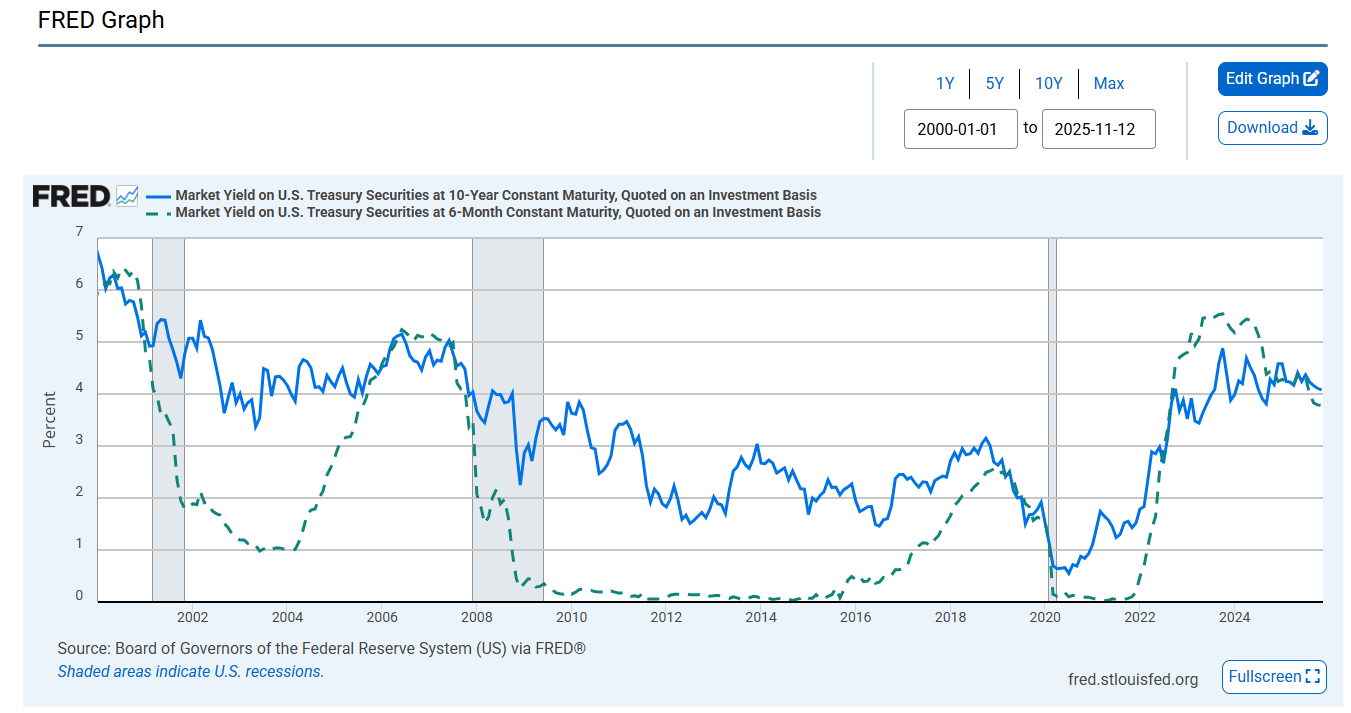

In [156]:
try:
    display(Image("data/US interest rates.png", width=1200))
except:
    pass

___

### For the European interest rates :


In [157]:
def download_ecb_yield_curve(series_key, start_date, output_file):
    try:
        base_url = "https://data-api.ecb.europa.eu/service/data" # Construct the ECB download URL (SDMX API)
        url = f"{base_url}/YC/{series_key}?startPeriod={start_date}"
        print(f"Downloading data from {url}") # Download the XML data
        response = requests.get(url)
        response.raise_for_status()
        
        root = ET.fromstring(response.content)
        namespaces = {
            'message': 'http://www.sdmx.org/resources/sdmxml/schemas/v2_1/message',
            'generic': 'http://www.sdmx.org/resources/sdmxml/schemas/v2_1/data/generic',
            'common': 'http://www.sdmx.org/resources/sdmxml/schemas/v2_1/common'
        }
        observations = root.findall('.//generic:Obs', namespaces)
        if not observations:
            observations = root.findall('.//Obs')
        
        data = []  # Extract the relevant data
        for obs in observations:
            time_elem = obs.find('.//generic:ObsDimension', namespaces)
            date = time_elem.get('value') if time_elem is not None else obs.get('TIME_PERIOD')
            value_elem = obs.find('.//generic:ObsValue', namespaces)
            rate = value_elem.get('value') if value_elem is not None else obs.get('OBS_VALUE')
            if date and rate:
                data.append({
                    'date': date,
                    'yield_rate': rate,
                })
        
        if data:  # Write to CSV
            with open(output_file, 'w', newline='', encoding='utf-8') as csvfile:
                fieldnames = ['date', 'yield_rate']
                writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
                writer.writeheader()
                writer.writerows(data)
            print(f"Saved {len(data)} records to {output_file}")
            print(f"Date range: {data[0]['date']} to {data[-1]['date']}")
        else:
            print("No data extracted from XML.")
    
    except requests.exceptions.RequestException as e:
        print(f"Error downloading data: {e}")
    except ET.ParseError as e:
        print(f"Error parsing XML: {e}")
    except Exception as e:
        print(f"Unexpected error: {e}")   

In [158]:
download_ecb_yield_curve(
    series_key='B.U2.EUR.4F.G_N_C.SV_C_YM.SR_6M',
    start_date='2000-01-01',
    output_file='data/ECB 6M.csv'
)

download_ecb_yield_curve(
    series_key='B.U2.EUR.4F.G_N_C.SV_C_YM.SR_10Y',
    start_date='2000-01-01',
    output_file='data/ECB 10Y.csv'
)

Saved 5420 records to data/ECB 6M.csv
Date range: 2004-09-06 to 2025-11-17
Saved 5420 records to data/ECB 10Y.csv
Date range: 2004-09-06 to 2025-11-17


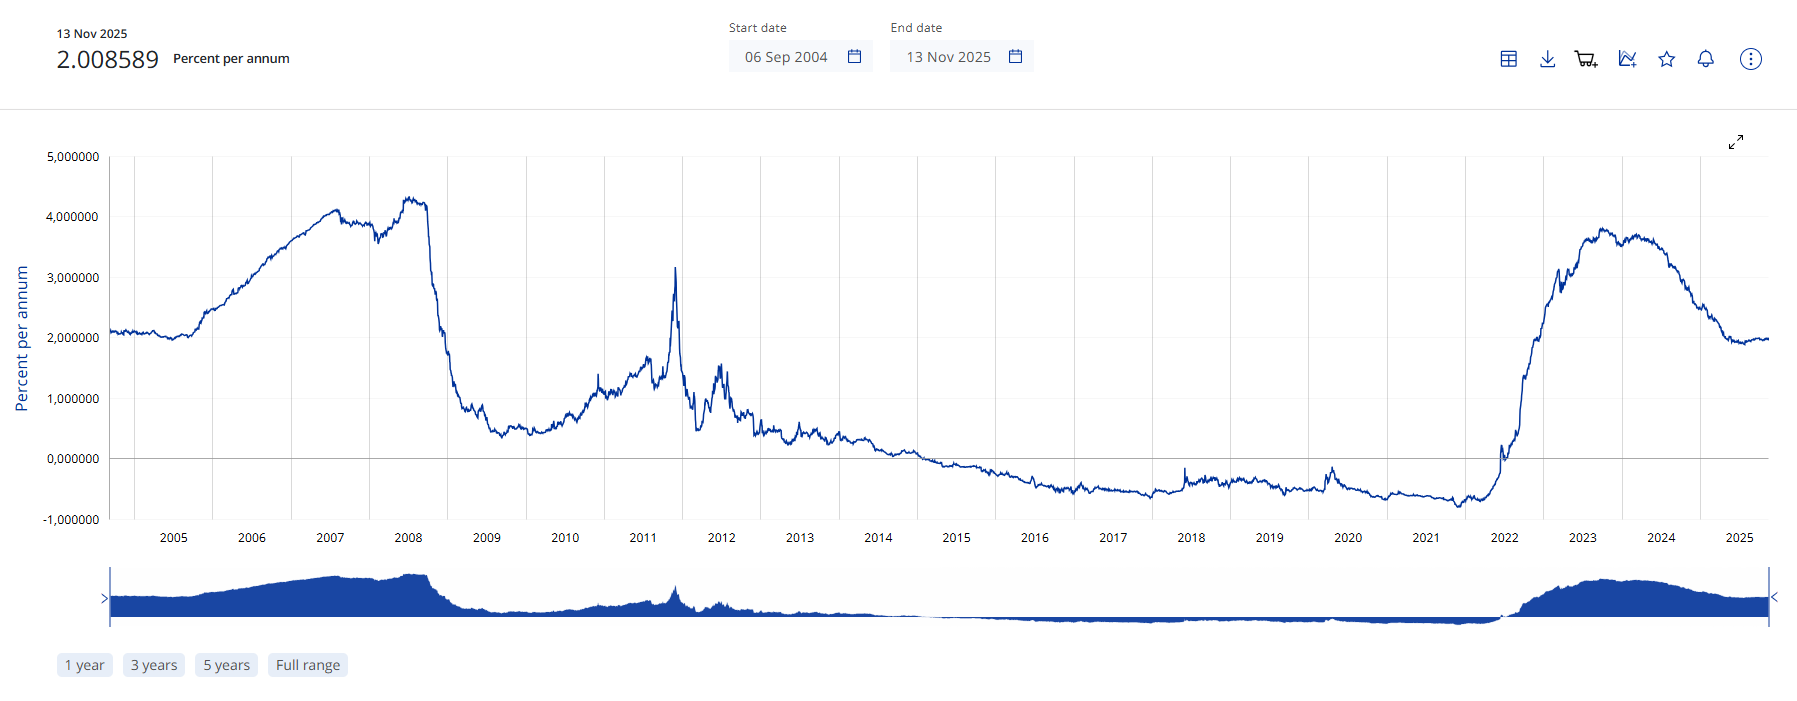

In [159]:
try:
    display(Image("data/ECB interest rates 6M.png", width=1200))
except:
    pass

___

We now extract the data from the downloaded files :

In [160]:
files = ['data/usd_eur_exchange_rates.csv', 'data/DGS10.csv', 'data/DGS6MO.csv', 'data/ECB 6M.csv', 'data/ECB 10Y.csv']
data_frames = {}
column_map = {
    'usd_eur_exchange_rates': 'exchange_rate',
    'DGS10': 'DGS10',
    'DGS6MO': 'DGS6MO',
    'ECB 6M': 'ECB6M',
    'ECB 10Y': 'ECB10Y'
}
for file in files:
    df = pd.read_csv(file)
    key = file.replace("data/","").replace(".csv","")
    if "date" in df.columns:
        df['date'] = pd.to_datetime(df['date'])
    elif 'observation_date' in df.columns:
        df['date'] = pd.to_datetime(df['observation_date'])
    rate_col = [c for c in df.columns if c not in ['date', 'observation_date']]
    if len(rate_col) != 1:
        print(f"Warning: unexpected columns in {file}: {rate_col}")
    rate_col = rate_col[0]
    df = df[['date', rate_col]].rename(columns={rate_col: column_map[key]})
    data_frames[key] = df

merged_df = reduce(lambda left, right: pd.merge(left, right, on='date', how='inner'), data_frames.values())
merged_df = merged_df.sort_values('date').reset_index(drop=True)
df = merged_df.copy()

In [161]:
print(df.head())
print(df.tail())

        date  exchange_rate  DGS10  DGS6MO     ECB6M    ECB10Y
0 2004-09-06         1.2071    NaN     NaN  2.102528  4.262767
1 2004-09-07         1.2079   4.26    1.91  2.118527  4.260667
2 2004-09-08         1.2039   4.18    1.88  2.129000  4.280397
3 2004-09-09         1.2191   4.22    1.88  2.112336  4.215735
4 2004-09-10         1.2219   4.19    1.87  2.095246  4.175095
           date  exchange_rate  DGS10  DGS6MO     ECB6M    ECB10Y
5414 2025-11-10         1.1571   4.13    3.79  1.998913  3.189146
5415 2025-11-11         1.1575    NaN     NaN  1.990815  3.170306
5416 2025-11-12         1.1576   4.08    3.78  1.998428  3.153618
5417 2025-11-13         1.1619   4.11    3.80  2.008589  3.178045
5418 2025-11-14         1.1648   4.14    3.80  2.005737  3.216541


___

### Analytics and learning strategies

Now that we have successfully downloaded and extracted all the required data for our model, I will try to fit different kind of machine learning algorithms. I will be using simple 1 day returns, as they are often small they are more or less equivalent to log returns : $ \ln(1+r_t) \sim r_t $


___

#### First function : signals

Every model is a different kind of regressor $R$, and they work as follows :

$R$ takes as arguments :
- Euro/US Exchange rate $r_t$
- ECB / US yields 6M/10Y at time $t$
- US yields spread / ECB yields spread at time $t$
- ECB / US yields 6M/10Y increase or decrease at time $t$ (so it also takes as arguments the yields at time $t-1$)

Its output is a prediction of the Euro/US Exchange rate $r_{t+2}$

The predicted exchange rate $r_{t+1}$ then gives the following signal :
- If  $r_{t+2} > \text{threshold}$, then go long of the exchange rate for day $t+2$
- If  $r_{t+2} > \text{threshold}$, then go short of the exchange rate for day $t+2$
- Else, do nothing

**Everyday the positions are reset**, and the prediction are made for the next day. When an order is issued, it means that we are simply buying 1 unit, or shorting 1 unit.

___

#### Second function : trade costs

For realism, I decided to add trade costs, which is a parameter that can be changed (it starts at 0 for the first simulation, and then I put it at 2bp, as I figured on Boursobank the lowest trading cost available is 10bp for the customers, it may be up to 5 times lower for financial firms).

___

#### Third function : strategy performance

Based on the predicted values and signals, we compute the equity of our model, which consists in computing the compounded returns over time as growth factor to compare it to safe yields

___

The other functions are pretty straight-forward.


Regarding the data partitioning strategy for training, validation, and test, I decided to split the dataset as follows :

- Optimization set, which is split again :
    - Train set
    - Validation set
- Test set

The optimization set contains a training set and a validation set, both used to fine-tune the different parameters of each model. Once the best parameters are found, we switch to the test step, which uses the whole optimization set as training set with the obtained parameters (so that it can't finetune the parameters on the current pnl, only the past pnl), and the model then computes the pnl on the yet untouched test set.


In [162]:
def generate_signals(pred, threshold_value):
    return np.where(pred > threshold_value, 1, np.where(pred < -threshold_value, -1, 0))

def trade_costs(sig, cost):
    changes = np.abs(np.diff(np.insert(sig, 0, 0)))
    return changes * cost

def strategy_performance(signals, cost, prices):
    simple_ret = prices.pct_change().shift(-1).iloc[:-1].to_numpy()
    n = min(len(signals), len(simple_ret), len(cost))
    strat = signals[:n] * simple_ret[:n] - cost[:n]
    equity = np.cumprod(1 + strat)
    return strat, equity

def sharpe(x,annual_days):
    if np.std(x) == 0: return -999
    return np.sqrt(annual_days) * np.mean(x) / np.std(x)

def to_xy(block, features, target):
    return block[features].to_numpy(), block[target].to_numpy()

I will also use different kind of parameters to try to be as close to reality as possible :

**OPT_PARAMETERS**

This parameter is the ratio in percentage of the data that is used to test and finetune the models. The smaller this value is, the bigger the size of the final test dataset. This value describes how much the hyperparameters are going to be fine-tuned when training the models.

**TEST_RATIO** 

This parameter is the ratio in percentage of the optimization data that is used to test the models. The smaller this value is, the bigger the size of the training dataset. The remaining test is untouched until the end, when the final PnL is calculated.

**YIELD_SHIFT**

It is a parameter I felt the need to add to the model, as I learnt when searching how rates are computed, that today's rates are often published tomorrow. This parameter allows the model not to be biased by knowing future information from today's rates to predict today's exchange rate.

**ANNUAL_DAYS** is just the number of trading days in a year

**THRESHOLD** was mentionned above to generate signal. If I want my model to always take a decision, I set it to 0.

In [163]:
def models(df,OPT_PARAMETERS,TEST_RATIO,YIELD_SHIFT,TRADE_COST,THRESHOLD,ANNUAL_DAYS,rep):
    for c in ["DGS10","DGS6MO","ECB10Y","ECB6M"]: # Observed values are only available with a lag (what the model actually sees)
        df[f"{c}_obs"] = df[c].shift(YIELD_SHIFT)
    df["return_1d_simple"] = df["exchange_rate"].pct_change().shift(-1) # Target: next-day simple return
    for c in ["DGS10","DGS6MO","ECB10Y","ECB6M"]: # Interest rates changes
        df[f"{c}_chg"] = df[f"{c}_obs"].diff()
    df["diff_10y"] = df["DGS10_obs"] - df["ECB10Y_obs"] # Spreads between US and ECB yields
    df["diff_6m"]  = df["DGS6MO_obs"] - df["ECB6M_obs"]

    FEATURES = [
        "exchange_rate",
        "DGS10_obs","DGS6MO_obs","ECB10Y_obs","ECB6M_obs",
        "DGS10_chg","DGS6MO_chg","ECB10Y_chg","ECB6M_chg",
        "diff_10y","diff_6m"
    ]
    TARGET = "return_1d_simple"

    df = df.dropna(subset=FEATURES + [TARGET]).copy() # Drop rows with NaNs in features/target to avoid messing with the regressors
    N = len(df)
    cut_opt = int(N * OPT_PARAMETERS)
    df_opt = df.iloc[:cut_opt].copy()    # Used only for hyperparameters + threshold optimization, and for regressor training
    df_final = df.iloc[cut_opt:].copy()  # This part of the dataset remains untouched until final evaluation

    cut_train_opt = int(len(df_opt) * (1 - TEST_RATIO)) # Inside df_opt, create train/validation split for tuning
    df_train_opt = df_opt.iloc[:cut_train_opt].copy()
    df_valid_opt = df_opt.iloc[cut_train_opt:].copy()

    X_train_opt, y_train_opt = to_xy(df_train_opt,FEATURES,TARGET)
    X_valid_opt, y_valid_opt = to_xy(df_valid_opt,FEATURES,TARGET)

    scaler = StandardScaler()
    X_train_opt_s = scaler.fit_transform(X_train_opt) # Fit the scaler only on training data (x - mu)/sigma
    X_valid_opt_s = scaler.transform(X_valid_opt) # Apply the same transformation to validation data

    param_grids = {
        "Ridge": {"alpha": [2,5,10]},
        "RandomForest": {"n_estimators": [3,4,5], "min_samples_leaf": [3,4,5,6]},
        "MLP": {"hidden_layer_sizes": [(6,6),(8,8),(10,10),(12,12)], "max_iter": [200]}
    }

    best_params = {}
    best_sharpe = {}

    for model_name, grid in param_grids.items():
        print(f"\nOptimizing {model_name}")
        keys = list(grid.keys())
        combinations = list(itertools.product(*grid.values()))
        best_model_sharpe = -1e9
        best_combo = None

        for combo in combinations:
            params = dict(zip(keys, combo))

            if model_name == "Ridge":
                model = Ridge(**params)
            elif model_name == "RandomForest":
                model = RandomForestRegressor(random_state=0, **params)
            elif model_name == "MLP":
                model = MLPRegressor(random_state=0, **params)
            else:
                continue

            model.fit(X_train_opt_s, y_train_opt) # Fit on the training part of optimization block
            pred_valid = model.predict(X_valid_opt_s) # Predict on the validation part of optimization block
            prices_valid = df_valid_opt["exchange_rate"]
            s = generate_signals(pred_valid, THRESHOLD)
            c = trade_costs(s, TRADE_COST)
            strat_ret, equity = strategy_performance(s, c, prices_valid)
            sh = sharpe(strat_ret,ANNUAL_DAYS)
            if np.isnan(sh):
                continue
            if sh > best_model_sharpe: # We use Sharpe ratio to select the best treshold
                best_model_sharpe = sh
                best_combo = params

        print(f"Best parameters : {best_combo}")
        best_params[model_name] = best_combo
        best_sharpe[model_name] = best_model_sharpe

    # Once the best parameters and thresholds have been found, we can evaluate the models on the final test block

    X_opt_full, y_opt_full = to_xy(df_opt,FEATURES,TARGET)
    scaler_full = StandardScaler()
    X_opt_full_s = scaler_full.fit_transform(X_opt_full)
    X_final, y_final = to_xy(df_final,FEATURES,TARGET)
    X_final_s = scaler_full.transform(X_final)

    results = {}
    plots_data = {}  # To store plot series for each model

    for model_name in param_grids.keys():
        params = best_params.get(model_name) # We get the best parameters found during optimization for each model
        print(f"\nFinal evaluation: {model_name}")
        if params is None:
            print(" No best params found during optimization; skipping.")
            continue
        if model_name == "Ridge":
            model = Ridge(**params)
        elif model_name == "RandomForest":
            model = RandomForestRegressor(random_state=0, **params)
        elif model_name == "MLP":
            model = MLPRegressor(random_state=0, **params)
        else:
            continue

        
        model.fit(X_opt_full_s, y_opt_full) # Fit on full optimization block
        pred_final = model.predict(X_final_s) # Predict on final (yet untouched) block
        signals = generate_signals(pred_final, THRESHOLD)
        costs = trade_costs(signals,TRADE_COST)
        prices = df_final["exchange_rate"]
        strat_ret, equity = strategy_performance(signals, costs, prices)
        if len(strat_ret) == 0:
            print(" Not enough data in final block to compute returns.")
            continue
        sh = sharpe(strat_ret,ANNUAL_DAYS)
        net_return = equity[-1] - 1.0    
        prices_vals = prices.values # Build buy-and-hold equity (aligned)
        bh_simple_returns = (prices_vals[1:] / prices_vals[:-1] - 1.0)
        n = min(len(bh_simple_returns), len(strat_ret))
        bh_equity = (1 + bh_simple_returns[:n]).cumprod()
        us10y_series = df_final["DGS10_obs"].iloc[:n].to_numpy() # Riskless yields using observed 10y in df_final
        ecb10y_series = df_final["ECB10Y_obs"].iloc[:n].to_numpy()
        us_daily = (us10y_series / 100.0) / ANNUAL_DAYS
        ecb_daily = (ecb10y_series / 100.0) / ANNUAL_DAYS
        us_equity = (1 + us_daily).cumprod()
        ecb_equity = (1 + ecb_daily).cumprod()

        eq = equity[:n]
        dates_aligned = df_final.index[1:n+1] #To aligne dates for the x axis

        plots_data[model_name] = { # Graph block
            "dates": dates_aligned,
            "strategy_equity": eq,
            "bh_equity": bh_equity,
            "us_equity": us_equity,
            "ecb_equity": ecb_equity
        }

        print(f" Sharpe: {sh:.3f}, Net Return: {net_return:.4f}")

    for model_name, data in plots_data.items():
        dates = data["dates"]
        plt.figure(figsize=(12,5))
        plt.plot(dates, data["strategy_equity"], label=f"{model_name} Equity")
        plt.plot(dates, data["bh_equity"], label="Buy & Hold EUR/USD")
        plt.plot(dates, data["us_equity"], label="US 10Y (riskless adjusted yield)", linestyle="--")
        plt.plot(dates, data["ecb_equity"], label="ECB 10Y (riskless adjusted yield)", linestyle=":")
        plt.title(f"{model_name} Strategy")
        plt.xlabel("Date")
        plt.ylabel("Portfolio value, start at 1.0")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(f"{rep}{model_name}_strategy_equity.png", dpi=300, bbox_inches='tight')
        plt.show()

___
### Empirical results : pnl analysis

Now for the initial test, no transaction cost, no threshold :

In [164]:
OPT_PARAMETERS = 0.8
TEST_RATIO = 0.25
YIELD_SHIFT = 2


Optimizing Ridge
Best parameters : {'alpha': 2}

Optimizing RandomForest
Best parameters : {'n_estimators': 5, 'min_samples_leaf': 6}

Optimizing MLP
Best parameters : {'hidden_layer_sizes': (8, 8), 'max_iter': 200}

Final evaluation: Ridge
 Sharpe: 0.323, Net Return: 0.0960

Final evaluation: RandomForest
 Sharpe: 0.490, Net Return: 0.1570

Final evaluation: MLP
 Sharpe: 0.840, Net Return: 0.2956


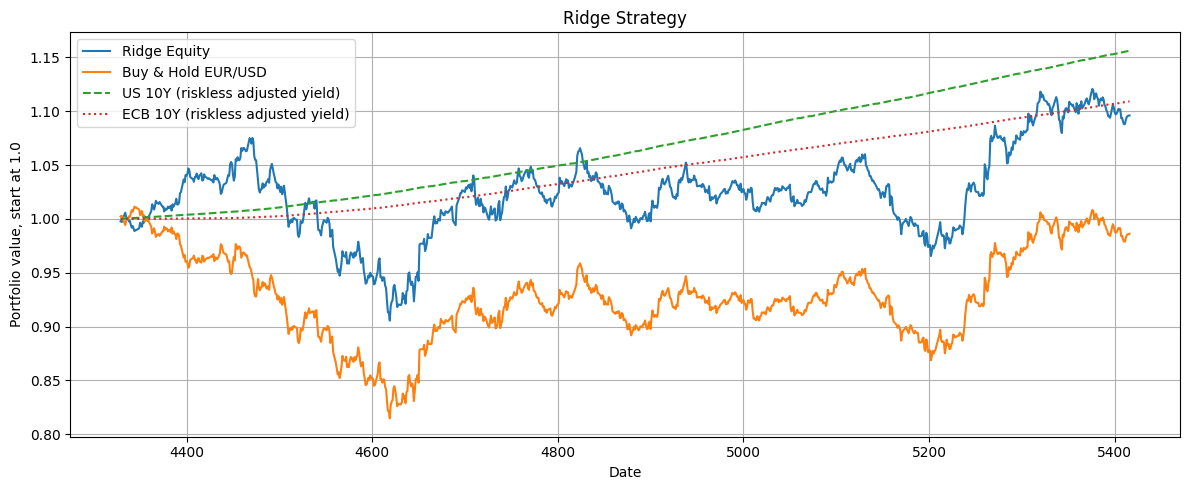

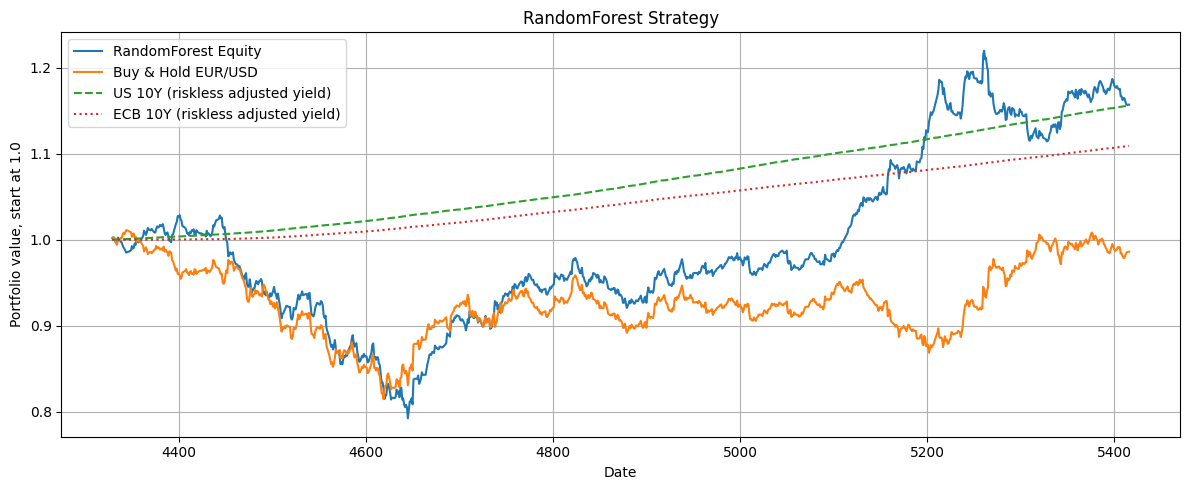

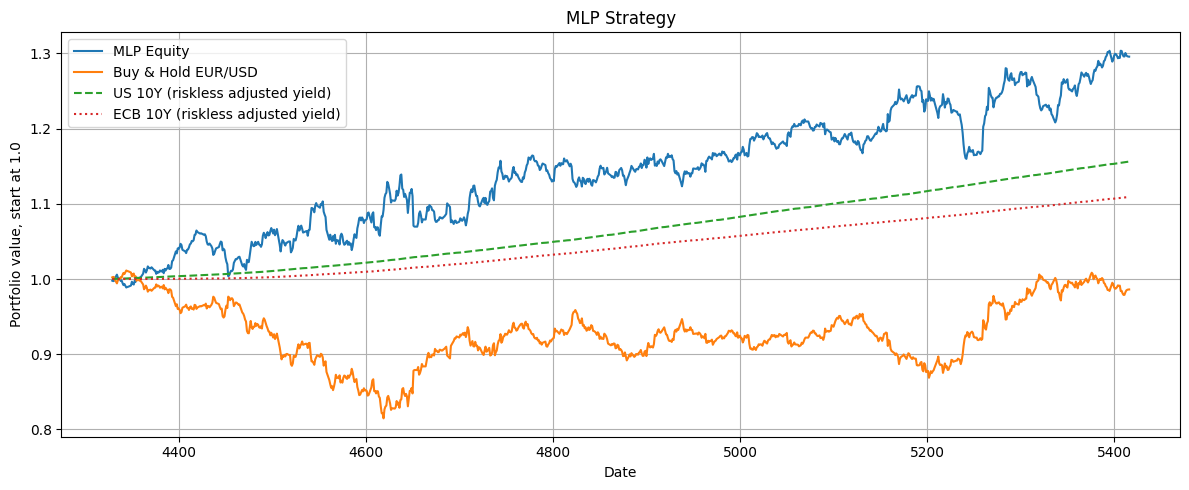

In [165]:
TRADE_COST = 0
THRESHOLD = 0
ANNUAL_DAYS = 252
df = merged_df.copy()
rep="data/Initial test/"
models(df,OPT_PARAMETERS,TEST_RATIO,YIELD_SHIFT,TRADE_COST,THRESHOLD,ANNUAL_DAYS,rep)

___



The test for PnL **starts in 2016 and ends today**.

Final evaluation: MLP
Sharpe: 0.840, Net Return: 0.2956

Here, we consider trading days, so it means the MLP algorithm made a **29.56% return** with **Sharpe ratio = 0.84** over 1010 trading days, which is equivalent to $\dfrac{1010}{262} \sim 3.85$ a little less than 4 years. Still impressive when compared to the adjusted 10Y yields.

We now introduce transaction costs, 2bp as explained when detailing the function. We also add a treshold for signals when predicting future exchange rates.


Optimizing Ridge
Best parameters : {'alpha': 2}

Optimizing RandomForest
Best parameters : {'n_estimators': 5, 'min_samples_leaf': 6}

Optimizing MLP
Best parameters : {'hidden_layer_sizes': (8, 8), 'max_iter': 200}

Final evaluation: Ridge
 Sharpe: 0.190, Net Return: 0.0496

Final evaluation: RandomForest
 Sharpe: 0.128, Net Return: 0.0285

Final evaluation: MLP
 Sharpe: 0.439, Net Return: 0.1382


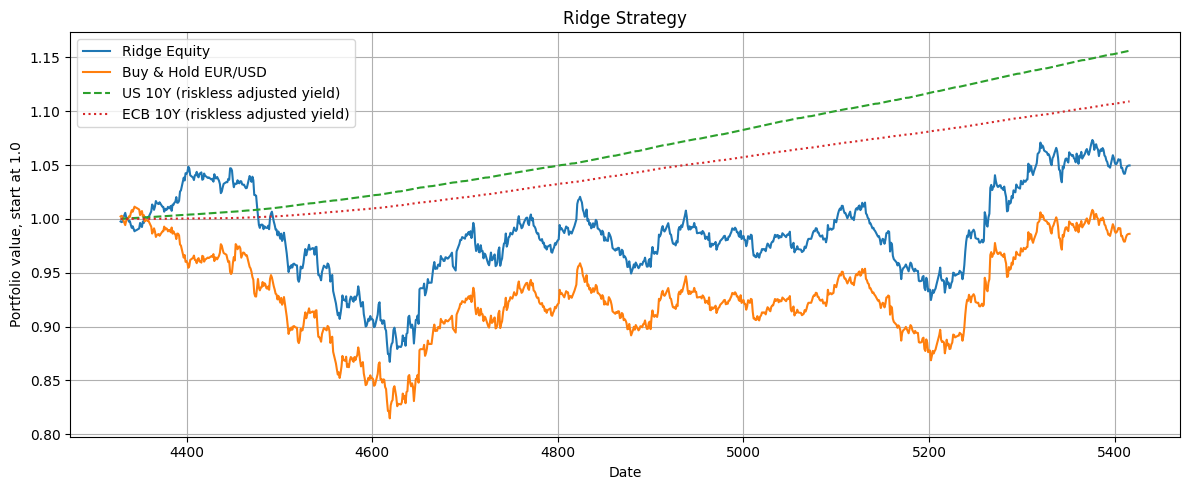

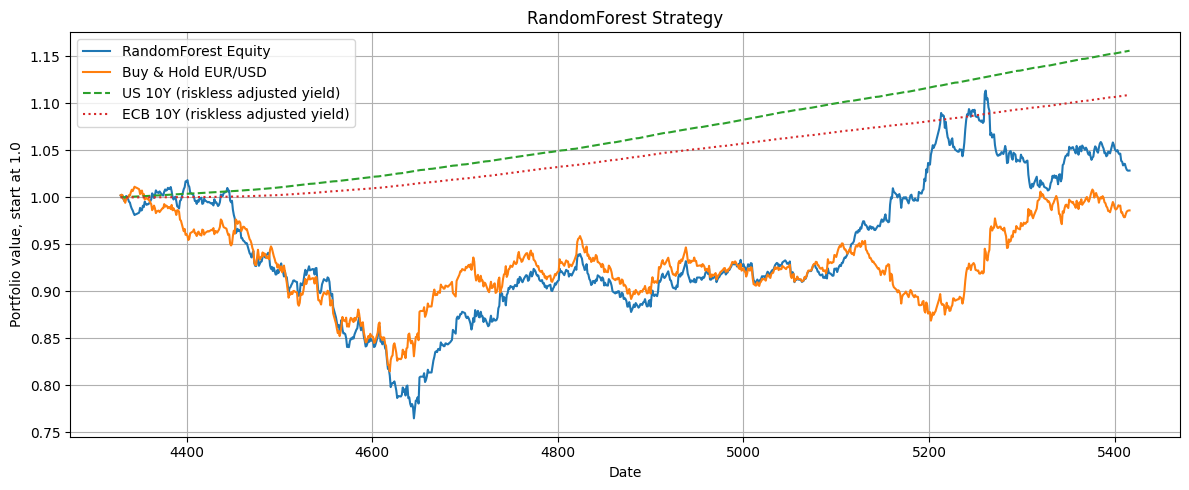

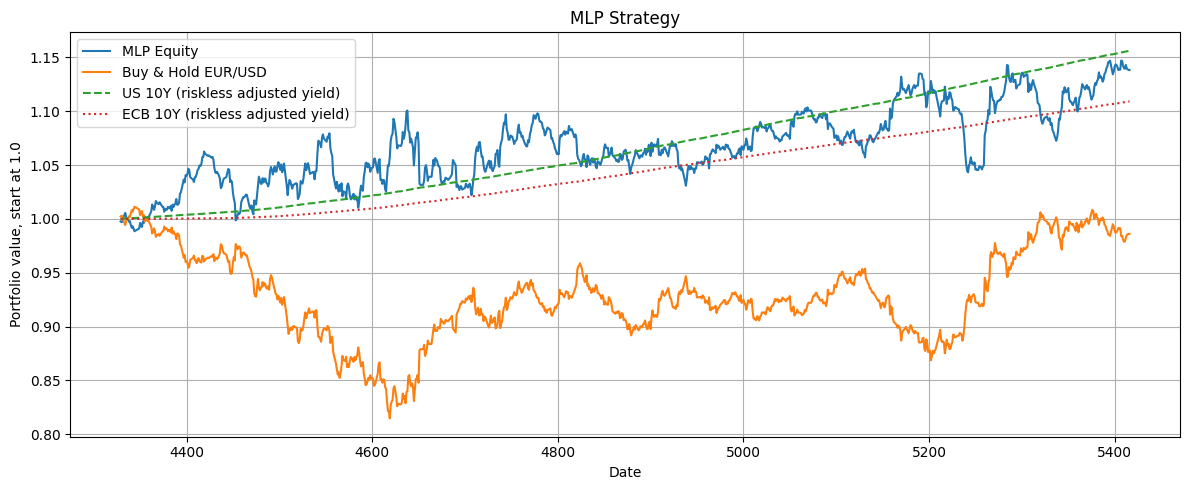

In [166]:
TRADE_COST = 0.0002
THRESHOLD = 0.00005
ANNUAL_DAYS = 252
df = merged_df.copy()
rep="data/Final test/"
models(df,OPT_PARAMETERS,TEST_RATIO,YIELD_SHIFT,TRADE_COST,THRESHOLD,ANNUAL_DAYS,rep)

Final evaluation: MLP
Sharpe: 0.439, Net Return: 0.1382

When adding those constraints, MLP model still managed to make **a net return of 13.82%** with a **Sharpe ratio of 0.439**.

Transactional costs and threshold change drastically how the different models train, and it changes their pnl. Still everytime MLP comes on top with the highest net return and Sharpe ratio.

___